In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import sys, os
from linearmodels.iv import IV2SLS

# Configuración de rutas e imports locales
sys.path.append(os.path.abspath(os.path.join('..')))
from src.models_econometrics import engle_granger_step1, adf_on_residuals, prepare_ecm_data

# Carga de datos (con la frecuencia MS que ya validamos)
df = pd.read_csv('../data/bitcoin_nasdaq_extended_py.csv', index_col='Date', parse_dates=True)
df = df.resample('MS').first().ffill().dropna()

**Test Cointegración Engle-Granger**

                            OLS Regression Results                            
Dep. Variable:                    btc   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     433.6
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           2.25e-55
Time:                        09:53:01   Log-Likelihood:                -1275.4
No. Observations:                 122   AIC:                             2557.
Df Residuals:                     119   BIC:                             2565.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.195e+04   1998.627    -15.988      0.0

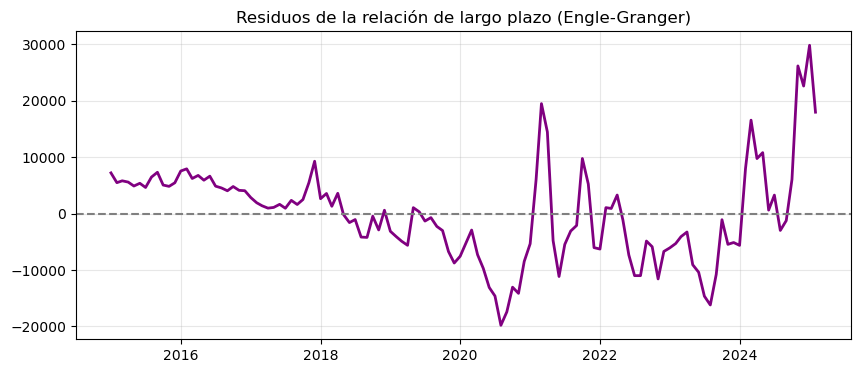

In [2]:
# Regresión de Largo Plazo
modelo_coint, resid_coint = engle_granger_step1(df['btc'], df[['nasdaq', 'fed_rate']])
print(modelo_coint.summary())

# Test ADF sobre Residuos
adf_res = adf_on_residuals(resid_coint)

print("\n--- TEST DE COINTEGRACIÓN (ADF sobre Residuos) ---")
print(f"Estadístico t (ADF): {adf_res[0]:.4f}")
print(f"Valor Crítico 1%: {adf_res[4]['1%']:.4f}")
print(f"Valor Crítico 5%: {adf_res[4]['5%']:.4f}")

# Conclusión
if adf_res[0] < adf_res[4]['5%']:
    print("\nRESULTADO: Existencia de Cointegración")
else:
    print("\nRESULTADO: No se encuentra evidencia de Cointegración")

# 3. Visualización de Residuos
plt.figure(figsize=(10, 4))
plt.plot(resid_coint, color='purple', lw=2)
plt.axhline(0, color='gray', linestyle='--')
plt.title('Residuos de la relación de largo plazo (Engle-Granger)')
plt.grid(alpha=0.3)
plt.show()

**Modelo de Correción de Error (ECM)**

Ya que si hay cointegración, ajustamos la velocidad en la que se ajusta

In [3]:
# Prepara datos
ecm_df = prepare_ecm_data(df, 'btc', ['nasdaq', 'fed_rate'], resid_coint)

# Estima ECM
X_ecm = sm.add_constant(ecm_df.drop(columns=['d_btc']))
y_ecm = ecm_df['d_btc']

ecm_fit = sm.OLS(y_ecm, X_ecm).fit()
print(ecm_fit.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_btc   R-squared:                       0.310
Model:                            OLS   Adj. R-squared:                  0.293
Method:                 Least Squares   F-statistic:                     17.54
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           1.80e-09
Time:                        09:53:01   Log-Likelihood:                -1194.9
No. Observations:                 121   AIC:                             2398.
Df Residuals:                     117   BIC:                             2409.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        337.5105    452.943      0.745      0.4

**Endogeneidad y Variables Instrumentales**

In [4]:
# Preparación de Instrumentos
df_iv = df.copy()
df_iv['fed_rate_L1'] = df_iv['fed_rate'].shift(1)
df_iv = df_iv.dropna()

# Creamos una serie de 'unos' para la constante
df_iv['const'] = 1

# Modelo MC2E
# Endógena: nasdaq | Instrumentos: fed_rate, fed_rate_L1
iv_mod = IV2SLS(
    dependent=df_iv['btc'],
    exog=df_iv['const'],        # Pasamos la columna de unos
    endog=df_iv['nasdaq'],
    instruments=df_iv[['fed_rate', 'fed_rate_L1']]
)

iv_res = iv_mod.fit()
print(iv_res.summary)

# Diagnósticos de MC2E
print("\n--- DIAGNÓSTICOS DEL MODELO IV ---")
print(f"Wu-Hausman (p-val): {iv_res.wu_hausman().pval:.4f}")
print(f"Sargan (p-val): {iv_res.sargan.pval:.4f}")

                          IV-2SLS Estimation Summary                          
Dep. Variable:                    btc   R-squared:                      0.8789
Estimator:                    IV-2SLS   Adj. R-squared:                 0.8779
No. Observations:                 121   F-statistic:                    173.12
Date:                Fri, Mar 13 2026   P-value (F-stat)                0.0000
Time:                        09:53:01   Distribution:                  chi2(1)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const      -3.172e+04     3880.7    -8.1729     0.0000  -3.932e+04  -2.411e+04
nasdaq         5.3064     0.4033     13.157     0.00